# Employee Attrition Prediction

**Machine Learning Minor Project**  
**Author:** Namami Sharma  
**College:** Samrat Ashoka Technological Institute, Vidisha

### Objective
Predict whether an employee is likely to leave the company (`Yes`) or stay (`No`) using employee-related information.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 2. Load the Dataset

Keep `Employee_Attrition_Dataset.csv` in the same folder as this notebook.

In [2]:
df = pd.read_csv('Employee_Attrition_Dataset.csv')
df.head()

,Age,Gender,Department,JobRole,MaritalStatus,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,JobInvolvement,EnvironmentSatisfaction,OverTime,BusinessTravel,DistanceFromHome,NumCompaniesWorked,TrainingTimesLastYear,StockOptionLevel,PerformanceRating,Education,Attrition
0,56,Male,Research & Development,Manager,Married,6412,1,4,4,2,3,No,Travel_Frequently,21,2,6,1,3,1,No
1,46,Female,Research & Development,Research Director,Married,15746,7,4,3,4,4,No,Travel_Rarely,25,4,3,2,3,4,No
2,32,Female,Sales,Sales Representative,Single,12904,7,1,2,2,4,Yes,Travel_Rarely,28,8,4,2,3,2,Yes
3,60,Male,Research & Development,Manager,Married,15229,3,4,3,4,2,Yes,Non-Travel,4,2,3,1,3,5,No
4,25,Male,Research & Development,Research Scientist,Married,8171,7,4,1,2,4,No,Non-Travel,18,9,5,2,4,2,No


In [ ]:
print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())


## 3. Understand the Dataset

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Department               1000 non-null   object
 3   JobRole                  1000 non-null   object
 4   MaritalStatus            1000 non-null   object
 5   MonthlyIncome            1000 non-null   int64 
 6   YearsAtCompany           1000 non-null   int64 
 7   JobSatisfaction          1000 non-null   int64 
 8   WorkLifeBalance          1000 non-null   int64 
 9   JobInvolvement           1000 non-null   int64 
 10  EnvironmentSatisfaction  1000 non-null   int64 
 11  OverTime                 1000 non-null   object
 12  BusinessTravel           1000 non-null   object
 13  DistanceFromHome         1000 non-null   int64 
 14  NumCompaniesWorked       1000 non-null   

In [5]:
print('Missing values in each column:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())


Missing values in each column:
Age                        0
Gender                     0
Department                 0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
YearsAtCompany             0
JobSatisfaction            0
WorkLifeBalance            0
JobInvolvement             0
EnvironmentSatisfaction    0
OverTime                   0
BusinessTravel             0
DistanceFromHome           0
NumCompaniesWorked         0
TrainingTimesLastYear      0
StockOptionLevel           0
PerformanceRating          0
Education                  0
Attrition                  0
dtype: int64

Duplicate rows: 0


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,39.014,12.333772,18.0,28.0,40.0,50.0,60.0
Gender,1000,2,Male,611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,1000,3,Research & Development,595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
JobRole,1000,9,Sales Executive,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaritalStatus,1000,3,Married,539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyIncome,1000.0,NaN,NaN,NaN,10883.541,5295.182817,1811.0,6230.75,10907.0,15414.25,19988.0
YearsAtCompany,1000.0,NaN,NaN,NaN,4.937,2.213579,0.0,3.0,5.0,6.0,15.0
JobSatisfaction,1000.0,NaN,NaN,NaN,2.476,1.116544,1.0,1.0,3.0,3.0,4.0
WorkLifeBalance,1000.0,NaN,NaN,NaN,2.499,1.139868,1.0,1.0,3.0,4.0,4.0
JobInvolvement,1000.0,NaN,NaN,NaN,2.534,1.13231,1.0,2.0,3.0,4.0,4.0


## 4. Exploratory Data Analysis (EDA)

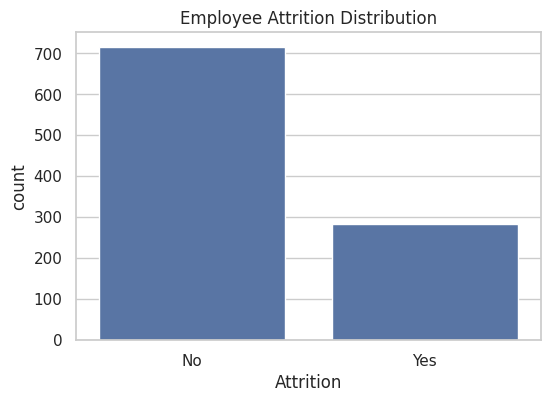

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition')
plt.title('Employee Attrition Distribution')
plt.show()


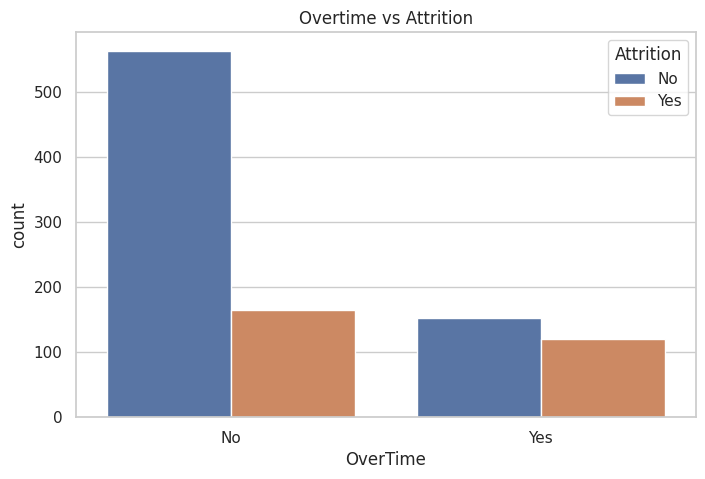

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition')
plt.title('Overtime vs Attrition')
plt.show()


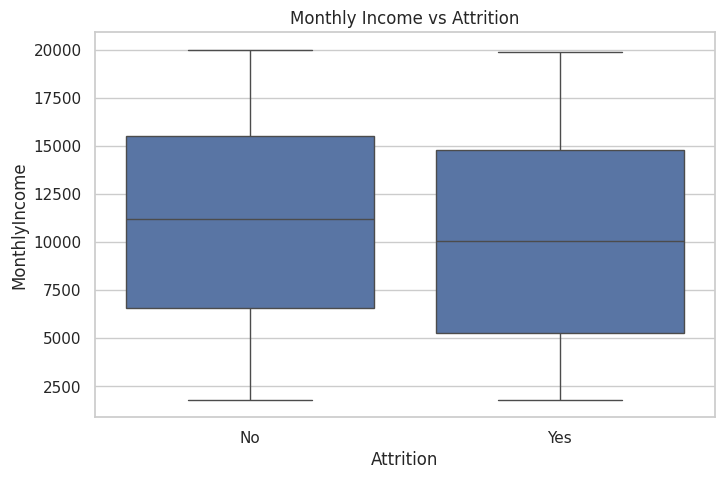

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome')
plt.title('Monthly Income vs Attrition')
plt.show()


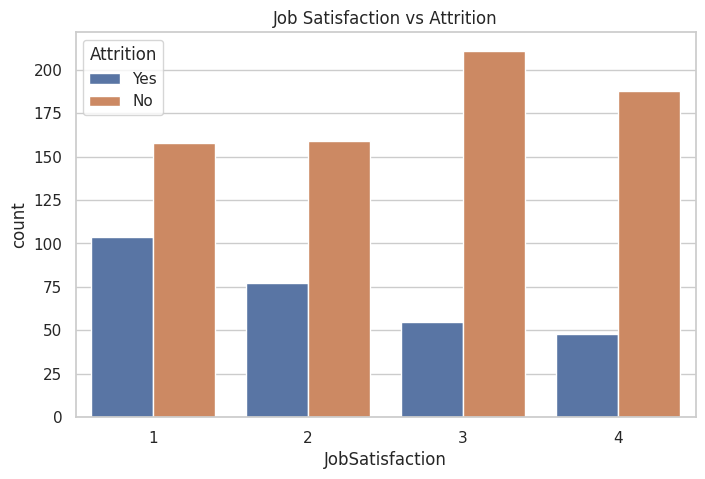

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Job Satisfaction vs Attrition')
plt.show()


## 5. Prepare Data for Machine Learning

The target column is `Attrition`. Categorical columns are converted into numerical form using One-Hot Encoding.

In [14]:
X = df.drop('Attrition', axis=1)
y = df['Attrition'].map({'No': 0, 'Yes': 1})

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

print('Categorical columns:', categorical_features)
print('Numeric columns:', numeric_features)

Categorical columns: ['Gender', 'Department', 'JobRole', 'MaritalStatus', 'OverTime', 'BusinessTravel']
Numeric columns: ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'EnvironmentSatisfaction', 'DistanceFromHome', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'StockOptionLevel', 'PerformanceRating', 'Education']


In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 800
Testing samples: 200


## 6. Train Machine Learning Models

In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0)
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.755,0.617647,0.368421,0.461538
1,Decision Tree,0.695,0.447368,0.298246,0.357895
2,Random Forest,0.750,0.705882,0.210526,0.324324


## 7. Evaluate the Models

In [18]:
for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)
    print('=' * 60)
    print(name)
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=['Stay', 'Leave'], zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

        Stay       0.78      0.91      0.84       143
       Leave       0.62      0.37      0.46        57

    accuracy                           0.76       200
   macro avg       0.70      0.64      0.65       200
weighted avg       0.74      0.76      0.73       200

Decision Tree
              precision    recall  f1-score   support

        Stay       0.75      0.85      0.80       143
       Leave       0.45      0.30      0.36        57

    accuracy                           0.69       200
   macro avg       0.60      0.58      0.58       200
weighted avg       0.67      0.69      0.67       200

Random Forest
              precision    recall  f1-score   support

        Stay       0.75      0.97      0.85       143
       Leave       0.71      0.21      0.32        57

    accuracy                           0.75       200
   macro avg       0.73      0.59      0.59       200
weighted avg       0.74   

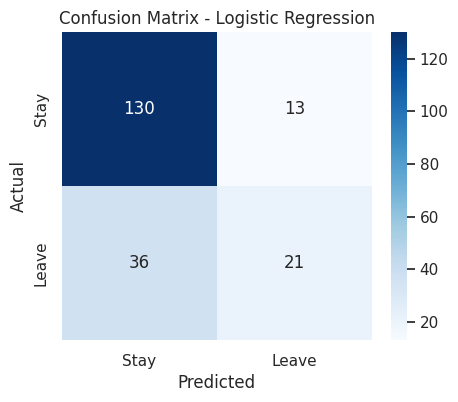

In [19]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_predictions = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'],
            yticklabels=['Stay', 'Leave'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


## 8. Make a Prediction for a New Employee

Change the values below to test the model with a new employee.

In [20]:
new_employee = pd.DataFrame([{
    'Age': 25,
    'Gender': 'Female',
    'Department': 'Sales',
    'JobRole': 'Sales Executive',
    'MaritalStatus': 'Single',
    'MonthlyIncome': 3500,
    'YearsAtCompany': 2,
    'JobSatisfaction': 2,
    'WorkLifeBalance': 2,
    'JobInvolvement': 2,
    'EnvironmentSatisfaction': 2,
    'OverTime': 'Yes',
    'BusinessTravel': 'Travel_Frequently',
    'DistanceFromHome': 15,
    'NumCompaniesWorked': 3,
    'TrainingTimesLastYear': 2,
    'StockOptionLevel': 0,
    'PerformanceRating': 3,
    'Education': 3
}])

prediction = best_model.predict(new_employee)[0]
probability = best_model.predict_proba(new_employee)[0][1]

print('Selected model:', best_model_name)
print('Prediction:', 'Employee may leave' if prediction == 1 else 'Employee may stay')
print(f'Estimated probability of attrition: {probability:.2%}')

Selected model: Logistic Regression
Prediction: Employee may leave
Estimated probability of attrition: 91.53%


## 9. Conclusion

This project demonstrates a complete Machine Learning workflow for employee attrition prediction: data loading, exploration, preprocessing, model training, evaluation and prediction.

**Note:** This dataset is synthetic and is intended for educational/project demonstration purposes. Model predictions should not be used as the sole basis for real employment decisions.